### **Student Name: Anwesh Rawat**
### **Group: L5CG7**
### **Student ID: 2408634**

# Assignment-1 - Statisitical Interpretation and Exploratory Data Analysis
# Analysis of the World Happiness Report : A Data-Driven Exploration of Global and Regional Trends.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3.1 Problem - 1: Getting Started with Data Exploration - Some Warm up Exercises:

### 1. Data Exploration and Understanding:

In [3]:
whdata=pd.read_csv("/content/drive/MyDrive/Concepts and Technologies of AI/Assignment 1/Datasets/WHR-2024-5CS037.csv")
whdata.head(10)

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298
5,Netherlands,7.319,1.901,1.462,0.706,0.725,0.247,0.372,1.906
6,Norway,7.302,1.952,1.517,0.704,0.835,0.224,0.484,1.586
7,Luxembourg,7.122,2.141,1.355,0.708,0.801,0.146,0.432,1.540
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488
9,Australia,7.057,1.854,1.461,0.692,0.756,0.225,0.323,1.745


In [4]:
whdata.shape#(rows,columns)

(143, 9)

In [5]:
whdata.dtypes

,0
Country name,object
score,float64
Log GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64
Dystopia + residual,float64


In [6]:
Score_mean=whdata['score'].mean()
Score_mean

5.52758041958042

In [7]:
Score_median=whdata['score'].median()
Score_median

5.785

In [8]:
Score_std=whdata['score'].std()
Score_std

1.1707165099442995

**Country with lowest and highest happiness score**

In [9]:
lowest_score=whdata[['Country name','score']][whdata['score']==whdata['score'].min()]
lowest_score

,Country name,score
142,Afghanistan,1.721


In [10]:
highest_score=whdata[['Country name','score']][whdata['score']==whdata['score'].max()]
highest_score

,Country name,score
0,Finland,7.741


**Missing values for dataset**

In [11]:
whdata.isnull().sum()

,0
Country name,0
score,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3
Perceptions of corruption,3
Dystopia + residual,3


**Countries with score greater than 7.5**

In [12]:
whdata_greater=whdata[whdata['score']>7.5]
whdata_greater.shape#Checking if the dataset contains many rows

(3, 9)

In [13]:
whdata_greater

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050


**Sorting the filtered dataset by GDP per capita in descending order**

In [14]:
whdata_greater_srt=whdata_greater.sort_values(by='Log GDP per capita',ascending=False)
whdata_greater_srt.head(10)

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082


**New Column Happiness_Category**

In [15]:
def categorize_happiness(score):
    if score >6:
        return 'High'
    elif score >= 4 and score<=6:
        return 'Medium'
    else:
        return 'Low'
whdata['Happiness_Category'] = whdata['score'].apply(categorize_happiness)
whdata.sample(5)

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category
65,Libya,5.866,1.526,1.100,0.550,0.592,0.111,0.204,1.785,Medium
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488,High
105,Namibia,4.832,1.266,1.212,0.307,0.470,0.069,0.061,1.446,Medium
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low
97,Turkiye,4.975,1.702,1.175,0.631,0.202,0.068,0.115,1.083,Medium


### 2. Data Visualizations:

**Bar Plot**

In [16]:
top_ten_happiness=whdata.sort_values(by='score',ascending=False).head(10)
top_ten_happiness

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category
0,Finland,7.741,1.844,1.572,0.695,0.859,0.142,0.546,2.082,High
1,Denmark,7.583,1.908,1.520,0.699,0.823,0.204,0.548,1.881,High
2,Iceland,7.525,1.881,1.617,0.718,0.819,0.258,0.182,2.050,High
3,Sweden,7.344,1.878,1.501,0.724,0.838,0.221,0.524,1.658,High
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298,High
5,Netherlands,7.319,1.901,1.462,0.706,0.725,0.247,0.372,1.906,High
6,Norway,7.302,1.952,1.517,0.704,0.835,0.224,0.484,1.586,High
7,Luxembourg,7.122,2.141,1.355,0.708,0.801,0.146,0.432,1.540,High
8,Switzerland,7.060,1.970,1.425,0.747,0.759,0.173,0.498,1.488,High
9,Australia,7.057,1.854,1.461,0.692,0.756,0.225,0.323,1.745,High


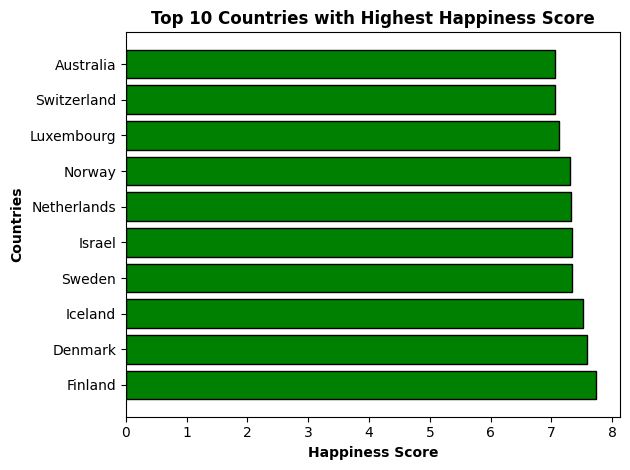

In [17]:
plt.barh(top_ten_happiness['Country name'],top_ten_happiness['score'],edgecolor='black',color='green')
plt.xlabel('Happiness Score',fontweight='bold')
plt.ylabel('Countries',fontweight='bold')
plt.title('Top 10 Countries with Highest Happiness Score',fontweight='bold')
plt.tight_layout()

**Line Plot**

In [18]:
top_ten_unhappiness=whdata.sort_values(by='score',ascending=True).head(10)
top_ten_unhappiness

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low
141,Lebanon,2.707,1.377,0.577,0.556,0.173,0.068,0.029,-0.073,Low
140,Lesotho,3.186,0.771,0.851,0.000,0.523,0.082,0.085,0.875,Low
139,Sierra Leone,3.245,0.654,0.566,0.253,0.469,0.181,0.053,1.068,Low
138,Congo (Kinshasa),3.295,0.534,0.665,0.262,0.473,0.189,0.072,1.102,Low
137,Zimbabwe,3.341,0.748,0.850,0.232,0.487,0.096,0.131,0.797,Low
136,Botswana,3.383,1.445,0.969,0.241,0.567,0.014,0.082,0.066,Low
135,Malawi,3.421,0.617,0.410,0.349,0.571,0.135,0.136,1.203,Low
134,Eswatini,3.502,1.255,0.925,0.176,0.284,0.059,0.116,0.686,Low
133,Zambia,3.502,0.899,0.809,0.264,0.727,0.168,0.109,0.526,Low


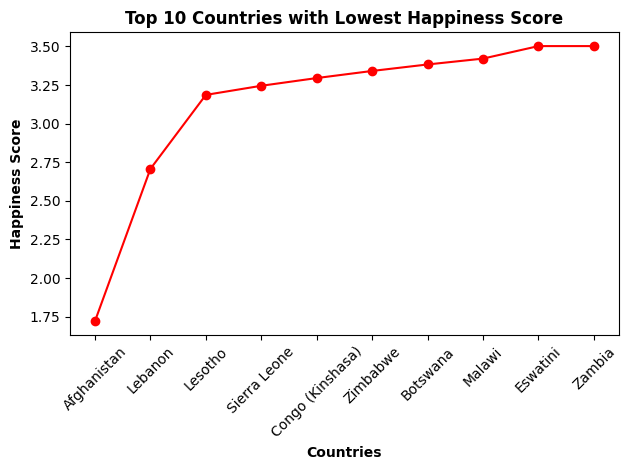

In [19]:
plt.plot(top_ten_unhappiness['Country name'],top_ten_unhappiness['score'],color='red',marker='o')
plt.xlabel('Countries',fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Happiness Score',fontweight='bold')
plt.title('Top 10 Countries with Lowest Happiness Score',fontweight='bold')
plt.tight_layout()

**Histogram**

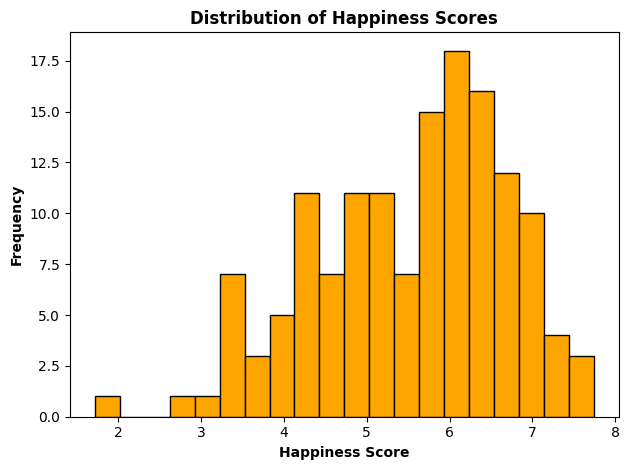

In [20]:
plt.hist(whdata['score'],bins=20,edgecolor='black',color='orange')
plt.xlabel('Happiness Score',fontweight='bold')
plt.ylabel('Frequency',fontweight='bold')
plt.title('Distribution of Happiness Scores',fontweight='bold')
plt.tight_layout()

**Scatter Plot**

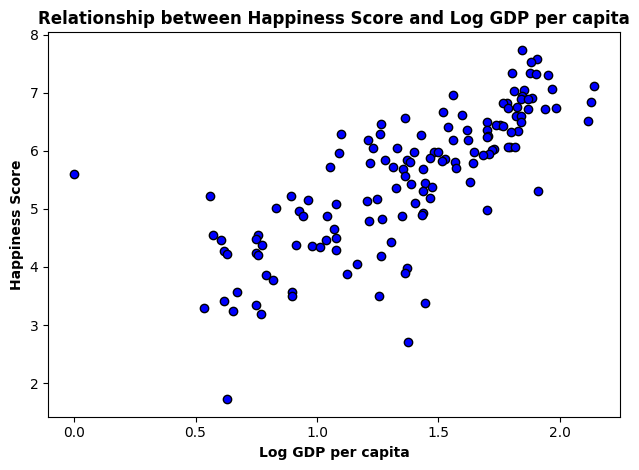

In [60]:
plt.scatter(whdata['Log GDP per capita'],whdata['score'],edgecolor='black',color='blue')
plt.xlabel('Log GDP per capita',fontweight='bold')
plt.ylabel('Happiness Score',fontweight='bold')
plt.title('Relationship between Happiness Score and Log GDP per capita',fontweight='bold')
plt.tight_layout()

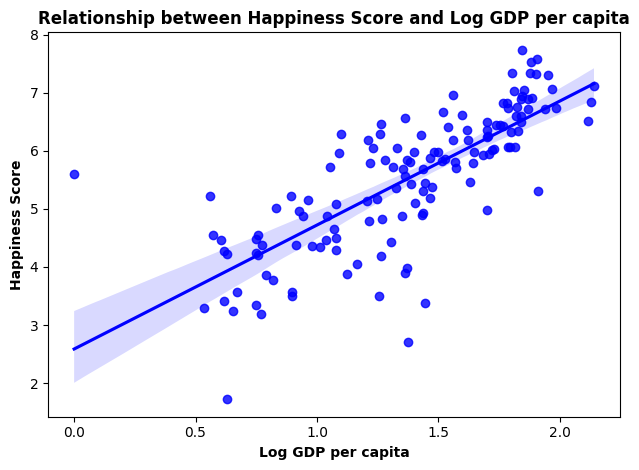

In [62]:
#Scatter Plot with trendline
sns.regplot(x=whdata['Log GDP per capita'],y=whdata['score'],color='blue',marker='o')
plt.xlabel('Log GDP per capita',fontweight='bold')
plt.ylabel('Happiness Score',fontweight='bold')
plt.title('Relationship between Happiness Score and Log GDP per capita',fontweight='bold')
plt.tight_layout()

## 3.2 Problem - 2 - Some Advance Data Exploration Task:

### Task - 1 - Setup Task - Preparing the South-Asia Dataset:

In [22]:
south_asian_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India",
"Maldives", "Nepal", "Pakistan", "Sri Lanka"]
south_asia_data = whdata[whdata["Country name"].isin(south_asian_countries)]
south_asia_data

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low


In [23]:
south_asia_data.to_csv("/content/drive/MyDrive/Concepts and Technologies of AI/Assignment 1/Datasets/south_asia_happiness.csv",index=False)

### Task - 2 - Composite Score Ranking:

In [66]:
#To prevent warning of pandas, loc is used
south_asia_data.loc[:,'composite_score'] = (0.40*south_asia_data['Log GDP per capita']) + (0.30*south_asia_data['Social support']) + (0.30*south_asia_data['Healthy life expectancy'])
south_asia_data

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score,GDP-Score-Gap
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159,-4.193
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039,-3.588
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874,-2.888
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739,-2.537
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774,-2.764
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238,-1.093


In [25]:
south_asia_data_srt=south_asia_data.sort_values(by='composite_score',ascending=False)
south_asia_data_srt

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238


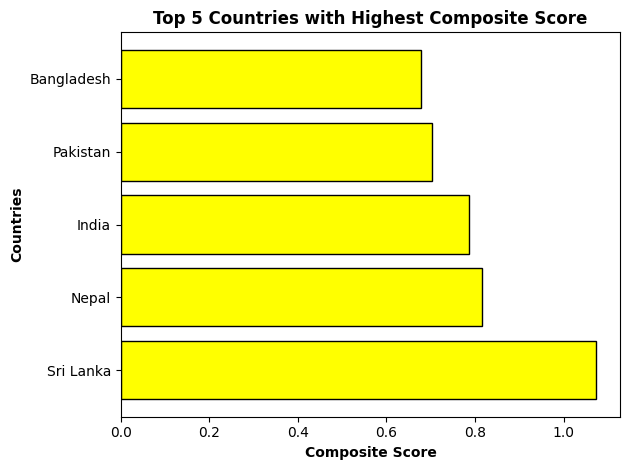

In [26]:
top_five_composite=south_asia_data_srt.head(5)
plt.barh(top_five_composite['Country name'],top_five_composite['composite_score'],edgecolor='black',color='yellow')
plt.xlabel('Composite Score',fontweight='bold')
plt.ylabel('Countries',fontweight='bold')
plt.title('Top 5 Countries with Highest Composite Score',fontweight='bold')
plt.tight_layout()

Rank Correlation: 0.6


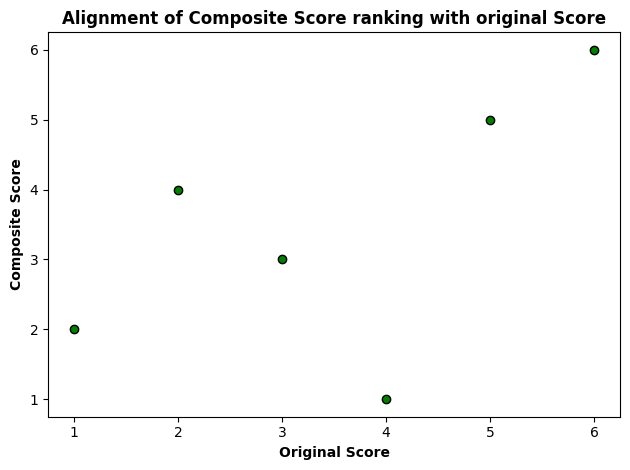

In [65]:
#Alignment of Composite Score ranking with original Score
composite_scores=south_asia_data['composite_score'].rank(ascending=False)
original_scores=south_asia_data['score'].rank(ascending=False)
rank_correlation=composite_scores.corr(original_scores,method='pearson')
print(f"Rank Correlation: {rank_correlation}")
plt.scatter(original_scores,composite_scores,edgecolor='black',color='green')
plt.ylabel('Composite Score',fontweight='bold')
plt.xlabel('Original Score',fontweight='bold')
plt.title('Alignment of Composite Score ranking with original Score',fontweight='bold')
plt.tight_layout()

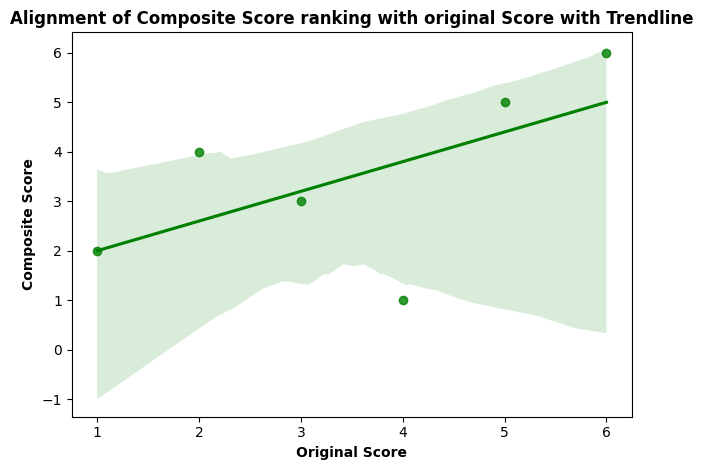

In [64]:
#with trendline
sns.regplot(y=composite_scores,x=original_scores,color='green',marker='o')
plt.ylabel('Composite Score',fontweight='bold')
plt.xlabel('Original Score',fontweight='bold')
plt.title('Alignment of Composite Score ranking with original Score with Trendline',fontweight='bold')
plt.tight_layout()

### Task - 3 - Outlier Detection:

In [28]:
#For GDP
#quantile does the sorting process internally
q1_gdp=south_asia_data['Log GDP per capita'].quantile(0.25)
q3_gdp=south_asia_data['Log GDP per capita'].quantile(0.75)
iqr_gdp=q3_gdp-q1_gdp
lower_bound_gdp=q1_gdp-1.5*iqr_gdp
upper_bound_gdp=q3_gdp+1.5*iqr_gdp
gdp_outliers=south_asia_data[(south_asia_data['Log GDP per capita']<lower_bound_gdp) | (south_asia_data['Log GDP per capita']>upper_bound_gdp)]
gdp_outliers

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score
142,Afghanistan,1.721,0.628,0.0,0.242,0.0,0.091,0.088,0.672,Low,0.3238


In [29]:
#For Score
q1_score=south_asia_data['score'].quantile(0.25)
q3_score=south_asia_data['score'].quantile(0.75)
iqr_score=q3_score-q1_score
lower_bound_score=q1_score-1.5*iqr_score
upper_bound_score=q3_score+1.5*iqr_score
score_outliers=south_asia_data[(south_asia_data['score']<lower_bound_score) | (south_asia_data['score']>upper_bound_score)]
score_outliers

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score
142,Afghanistan,1.721,0.628,0.0,0.242,0.0,0.091,0.088,0.672,Low,0.3238


In [68]:
pearson_GDP_score=south_asia_data['Log GDP per capita'].corr(south_asia_data['score'],method='pearson')
pearson_GDP_score

0.583969319428558

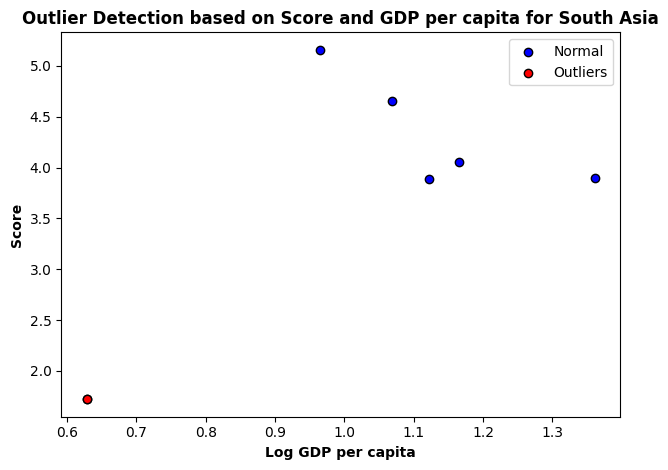

In [30]:
plt.scatter(south_asia_data['Log GDP per capita'],south_asia_data['score'],edgecolor='black',color='blue',label='Normal')
plt.scatter(gdp_outliers['Log GDP per capita'],gdp_outliers['score'],edgecolor='black',color='red',label='Outliers')
plt.xlabel('Log GDP per capita',fontweight='bold')
plt.ylabel('Score',fontweight='bold')
plt.title('Outlier Detection based on Score and GDP per capita for South Asia',fontweight='bold')
plt.legend()
plt.tight_layout()

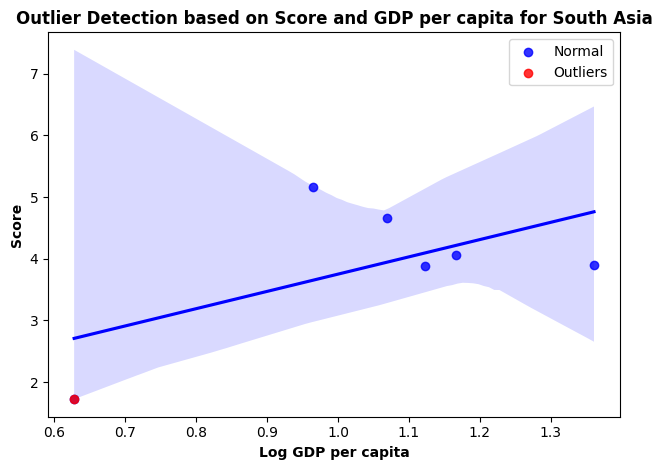

In [69]:
#with trendline
sns.regplot(x=south_asia_data['Log GDP per capita'],y=south_asia_data['score'],color='blue',marker='o',label='Normal')
sns.regplot(x=gdp_outliers['Log GDP per capita'],y=gdp_outliers['score'],color='red',marker='o',label='Outliers')
plt.xlabel('Log GDP per capita',fontweight='bold')
plt.ylabel('Score',fontweight='bold')
plt.title('Outlier Detection based on Score and GDP per capita for South Asia',fontweight='bold')
plt.legend()
plt.tight_layout()

### Task - 4 - Exploring Trends Across Metrics:

In [31]:
pearson_score_lifechoices=south_asia_data['score'].corr(south_asia_data['Freedom to make life choices'],method='pearson')
pearson_score_lifechoices

0.8005185224163315

In [32]:
pearson_score_generosity=south_asia_data['score'].corr(south_asia_data['Generosity'],method='pearson')
pearson_score_generosity

0.874512371253192

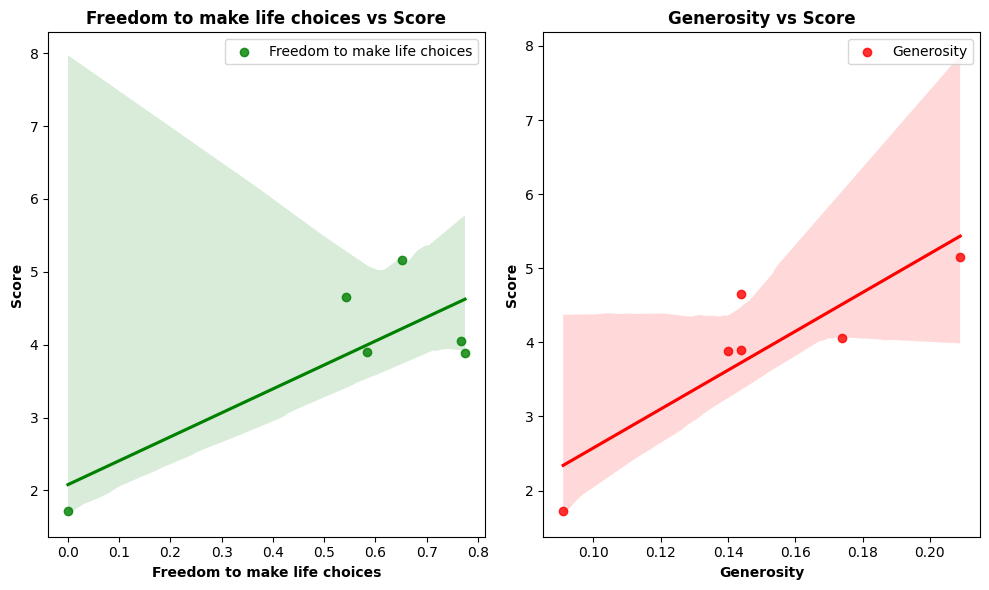

In [33]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.regplot(x=south_asia_data['Freedom to make life choices'],y=south_asia_data['score'],color='green',marker='o',label='Freedom to make life choices')
plt.ylabel('Score',fontweight='bold')
plt.xlabel('Freedom to make life choices',fontweight='bold')
plt.legend()
plt.title('Freedom to make life choices vs Score',fontweight='bold')
plt.subplot(1,2,2)
sns.regplot(x=south_asia_data['Generosity'],y=south_asia_data['score'],color='red',marker='o',label='Generosity')
plt.xlabel('Generosity',fontweight='bold')
plt.ylabel('Score',fontweight='bold')
plt.legend()
plt.title('Generosity vs Score',fontweight='bold')
plt.tight_layout()

### Task - 5 - Gap Analysis:

In [70]:
south_asia_data.loc[:,'GDP-Score-Gap']=south_asia_data['Log GDP per capita']-south_asia_data['score']
south_asia_data

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score,GDP-Score-Gap
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159,-4.193
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039,-3.588
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874,-2.888
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739,-2.537
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774,-2.764
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238,-1.093


In [35]:
southasian_gdpgap_ascending=south_asia_data.sort_values(by='GDP-Score-Gap',ascending=True)
southasian_gdpgap_ascending

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score,GDP-Score-Gap
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159,-4.193
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039,-3.588
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874,-2.888
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774,-2.764
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739,-2.537
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238,-1.093


In [36]:
southasian_gdpgap_descending=south_asia_data.sort_values(by='GDP-Score-Gap',ascending=False)
southasian_gdpgap_descending

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score,GDP-Score-Gap
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238,-1.093
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739,-2.537
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774,-2.764
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874,-2.888
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039,-3.588
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159,-4.193


In [37]:
#Country with higher GDP compared to score
largest_positive_gap=southasian_gdpgap_descending.head(3)
largest_positive_gap

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score,GDP-Score-Gap
142,Afghanistan,1.721,0.628,0.000,0.242,0.000,0.091,0.088,0.672,Low,0.3238,-1.093
127,Sri Lanka,3.898,1.361,1.179,0.586,0.583,0.144,0.031,0.014,Low,1.0739,-2.537
128,Bangladesh,3.886,1.122,0.249,0.513,0.775,0.140,0.167,0.919,Low,0.6774,-2.764


In [38]:
#Countries with lower GDP compared to score
largest_negative_gap=southasian_gdpgap_ascending.head(3)
largest_negative_gap

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score,GDP-Score-Gap
92,Nepal,5.158,0.965,0.990,0.443,0.653,0.209,0.115,1.783,Medium,0.8159,-4.193
107,Pakistan,4.657,1.069,0.600,0.321,0.542,0.144,0.074,1.907,Medium,0.7039,-3.588
125,India,4.054,1.166,0.653,0.417,0.767,0.174,0.122,0.756,Medium,0.7874,-2.888


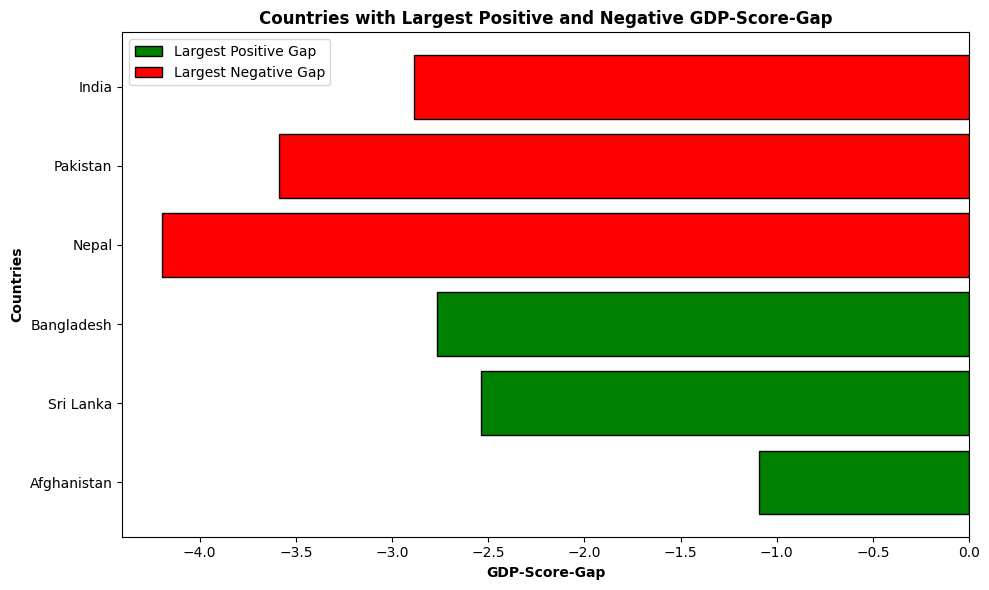

In [39]:
plt.figure(figsize=(10,6))
plt.barh(largest_positive_gap['Country name'],largest_positive_gap['GDP-Score-Gap'],edgecolor='black',color='green',label='Largest Positive Gap')
plt.barh(largest_negative_gap['Country name'],largest_negative_gap['GDP-Score-Gap'],edgecolor='black',color='red',label='Largest Negative Gap')
plt.xlabel('GDP-Score-Gap',fontweight='bold')
plt.ylabel('Countries',fontweight='bold')
plt.title('Countries with Largest Positive and Negative GDP-Score-Gap',fontweight='bold')
plt.legend()
plt.tight_layout()

## 3.3 Problem - 3 - Comparative Analysis:

In [40]:
middle_east_countries = [ "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
"Kuwait", "Lebanon", "Oman", "State of Palestine", "Qatar", "Saudi Arabia", "Syria",
"United Arab Emirates", "Yemen"]
middle_east_data = whdata[whdata["Country name"].isin(middle_east_countries)]
middle_east_data

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298,High
12,Kuwait,6.951,1.845,1.364,0.661,0.827,0.200,0.172,1.884,High
21,United Arab Emirates,6.733,1.983,1.164,0.563,0.815,0.209,0.258,1.741,High
27,Saudi Arabia,6.594,1.842,1.361,0.511,0.787,0.114,0.188,1.790,High
61,Bahrain,5.959,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
91,Iraq,5.166,1.249,0.996,0.498,0.425,0.141,0.048,1.809,Medium
99,Iran,4.923,1.435,1.136,0.571,0.366,0.235,0.123,1.057,Medium
102,State of Palestine,4.879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
124,Jordan,4.186,1.262,0.983,0.594,0.593,0.059,0.189,0.504,Medium
132,Yemen,3.561,0.671,1.281,0.293,0.362,0.080,0.113,0.760,Low


In [41]:
#As Bahrain and Palestine have missing values in every column except score, we will drop these rows
middle_east_data=middle_east_data.dropna()
middle_east_data

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category
4,Israel,7.341,1.803,1.513,0.740,0.641,0.153,0.193,2.298,High
12,Kuwait,6.951,1.845,1.364,0.661,0.827,0.200,0.172,1.884,High
21,United Arab Emirates,6.733,1.983,1.164,0.563,0.815,0.209,0.258,1.741,High
27,Saudi Arabia,6.594,1.842,1.361,0.511,0.787,0.114,0.188,1.790,High
91,Iraq,5.166,1.249,0.996,0.498,0.425,0.141,0.048,1.809,Medium
99,Iran,4.923,1.435,1.136,0.571,0.366,0.235,0.123,1.057,Medium
124,Jordan,4.186,1.262,0.983,0.594,0.593,0.059,0.189,0.504,Medium
132,Yemen,3.561,0.671,1.281,0.293,0.362,0.080,0.113,0.760,Low
141,Lebanon,2.707,1.377,0.577,0.556,0.173,0.068,0.029,-0.073,Low


**Descriptive Statistics:**

In [42]:
print(f"Mean Score for South Asian Countries: {south_asia_data['score'].mean()}")
print(f"Mean Score for Middle East Countries: {middle_east_data['score'].mean()}")
print(f"Standard Deviation for South Asian Countries: {south_asia_data['score'].std()}")
print(f"Standard Deviation for Middle East Countries: {middle_east_data['score'].std()}")

Mean Score for South Asian Countries: 3.895666666666667
Mean Score for Middle East Countries: 5.351333333333333
Standard Deviation for South Asian Countries: 1.1770690152521504
Standard Deviation for Middle East Countries: 1.648656346847335


**Middle East countries have highest happiness score on average**

**Top and Bottom Performers:**

In [43]:
#Creating dataframes for top/bottom of each regions
top3scores_southasian=south_asia_data.sort_values(by='score',ascending=False).head(3)
bottom3scores_southasian=south_asia_data.sort_values(by='score',ascending=True).head(3)
top3scores_middleeast=middle_east_data.sort_values(by='score',ascending=False).head(3)
bottom3scores_middleeast=middle_east_data.sort_values(by='score',ascending=True).head(3)

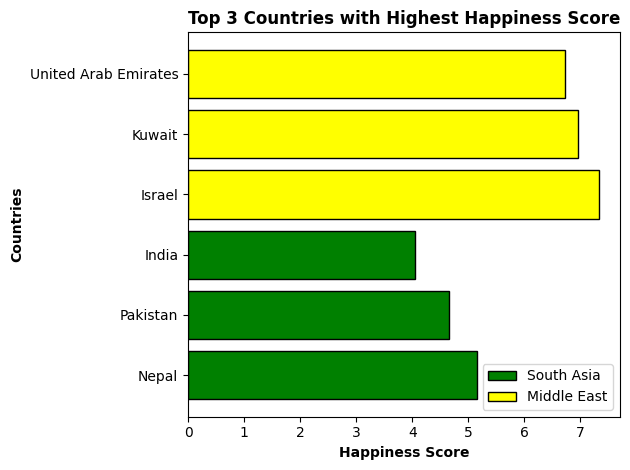

In [44]:
plt.barh(top3scores_southasian['Country name'],top3scores_southasian['score'],edgecolor='black',color='green',label='South Asia')
plt.barh(top3scores_middleeast['Country name'],top3scores_middleeast['score'],edgecolor='black',color='yellow',label='Middle East')
plt.xlabel('Happiness Score',fontweight='bold')
plt.ylabel('Countries',fontweight='bold')
plt.title('Top 3 Countries with Highest Happiness Score',fontweight='bold')
plt.legend()
plt.tight_layout()

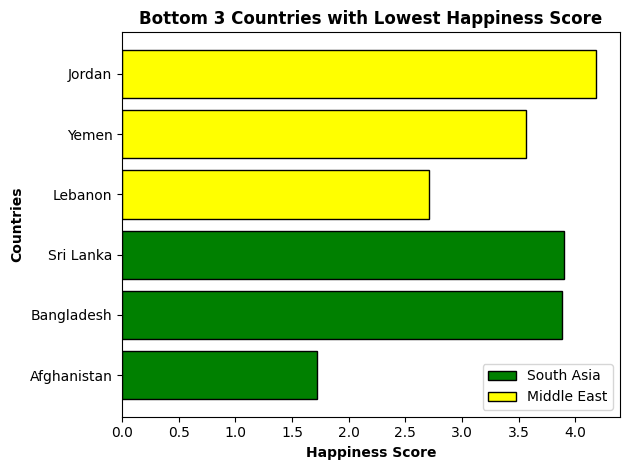

In [45]:
plt.barh(bottom3scores_southasian['Country name'],bottom3scores_southasian['score'],edgecolor='black',color='green',label='South Asia')
plt.barh(bottom3scores_middleeast['Country name'],bottom3scores_middleeast['score'],edgecolor='black',color='yellow',label='Middle East')
plt.xlabel('Happiness Score',fontweight='bold')
plt.ylabel('Countries',fontweight='bold')
plt.title('Bottom 3 Countries with Lowest Happiness Score',fontweight='bold')
plt.legend()
plt.tight_layout()

 **Metric Comparisons:**

In [46]:
metrics=['Log GDP per capita','Social support','Healthy life expectancy']
southasian_metrics=south_asia_data[metrics].mean()
middleeast_metrics=middle_east_data[metrics].mean()
combined_metrics=pd.concat([southasian_metrics,middleeast_metrics],axis=1)
combined_metrics.columns=['South Asia','Middle East']
combined_metrics

,South Asia,Middle East
Log GDP per capita,1.051833,1.496333
Social support,0.611833,1.152778
Healthy life expectancy,0.420333,0.554111


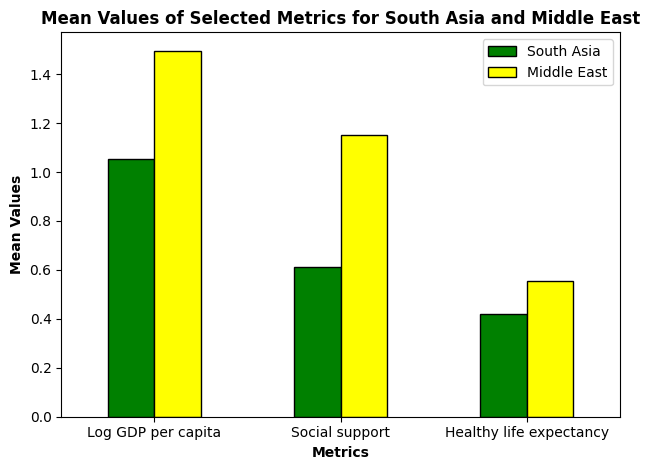

In [47]:
combined_metrics.plot(kind='bar',edgecolor='black',color=['green','yellow'])
plt.xlabel('Metrics',fontweight='bold')
plt.ylabel('Mean Values',fontweight='bold')
plt.xticks(rotation=0)
plt.title('Mean Values of Selected Metrics for South Asia and Middle East',fontweight='bold')
plt.tight_layout()

**Happiness Disparity**

In [48]:
south_asia_range = south_asia_data['score'].max() - south_asia_data['score'].min()
south_asia_cv = (south_asia_data['score'].std() / south_asia_data['score'].mean())*100

middle_east_range = middle_east_data['score'].max() - middle_east_data['score'].min()
middle_east_cv = (middle_east_data['score'].std() / middle_east_data['score'].mean())*100

print(f"South Asia: Range = {south_asia_range:.2f}, CV = {south_asia_cv:.2f}%")
print(f"Middle East: Range = {middle_east_range:.2f}, CV = {middle_east_cv:.2f}%")

if south_asia_cv>middle_east_cv:
  print("South Asia has higher variability in happiness score")
else:
  print("Middle East has higher variability in happiness score")

South Asia: Range = 3.44, CV = 30.21%
Middle East: Range = 4.63, CV = 30.81%
Middle East has higher variability in happiness score


**Correlation Analysis**

In [74]:
southasian_score_lifechoices=south_asia_data['Freedom to make life choices'].corr(south_asia_data['score'],method='pearson')
southasian_score_generosity=south_asia_data['Generosity'].corr(south_asia_data['score'],method='pearson')
middleeast_score_lifechoices=middle_east_data['Freedom to make life choices'].corr(middle_east_data['score'],method='pearson')
middleeast_score_generosity=middle_east_data['Generosity'].corr(middle_east_data['score'],method='pearson')
print(f"South Asia: \nFreedom to make life choices and score correlation = {southasian_score_lifechoices:.2f},\nGenerosity and score correlation = {southasian_score_generosity:.2f}")
print(f"Middle East:\nFreedom to make life choices and score correlation = {middleeast_score_lifechoices:.2f},\nGenerosity and score correlation = {middleeast_score_generosity:.2f}")

South Asia: 
Freedom to make life choices and score correlation = 0.80,
Generosity and score correlation = 0.87
Middle East:
Freedom to make life choices and score correlation = 0.86,
Generosity and score correlation = 0.63


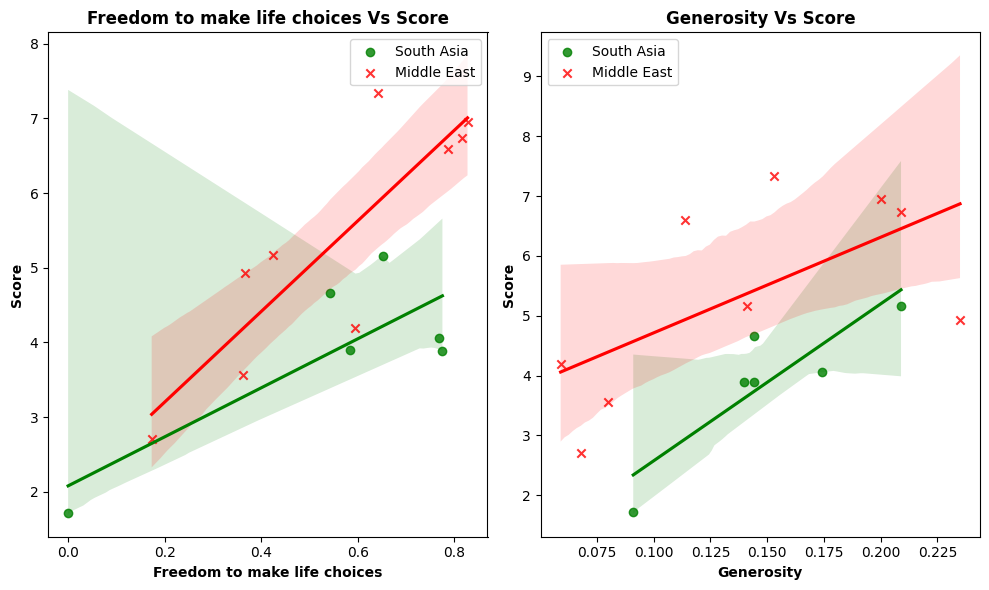

In [73]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.regplot(x=south_asia_data['Freedom to make life choices'],y=south_asia_data['score'],marker='o',color='green',label='South Asia')
sns.regplot(x=middle_east_data['Freedom to make life choices'],y=middle_east_data['score'],marker='x',color='red',label='Middle East')
plt.xlabel('Freedom to make life choices',fontweight='bold')
plt.ylabel('Score',fontweight='bold')
plt.title('Freedom to make life choices Vs Score',fontweight='bold')
plt.legend()
plt.subplot(1,2,2)
sns.regplot(x=south_asia_data['Generosity'],y=south_asia_data['score'],marker='o',color='green',label='South Asia')
sns.regplot(x=middle_east_data['Generosity'],y=middle_east_data['score'],marker='x',color='red',label='Middle East')
plt.xlabel('Generosity',fontweight='bold')
plt.ylabel('Score',fontweight='bold')
plt.title('Generosity Vs Score',fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()

**Outlier Detection**

In [51]:
#For south asia, the previously computed outliers will be used
gdp_outliers

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score
142,Afghanistan,1.721,0.628,0.0,0.242,0.0,0.091,0.088,0.672,Low,0.3238


In [52]:
score_outliers

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category,composite_score
142,Afghanistan,1.721,0.628,0.0,0.242,0.0,0.091,0.088,0.672,Low,0.3238


In [53]:
#For middle east
middleeast_q1_gdp=middle_east_data['Log GDP per capita'].quantile(0.25)
middleeast_q2_gdp=middle_east_data['Log GDP per capita'].quantile(0.75)
middleeast_iqr_gdp=middleeast_q2_gdp-middleeast_q1_gdp
middleeast_lower_bound_gdp=middleeast_q1_gdp-1.5*middleeast_iqr_gdp
middleeast_upper_bound_gdp=middleeast_q2_gdp+1.5*middleeast_iqr_gdp
middleeast_gdp_outliers=middle_east_data[(middle_east_data['Log GDP per capita']<middleeast_lower_bound_gdp) | (middle_east_data['Log GDP per capita']>middleeast_upper_bound_gdp)]
middleeast_gdp_outliers

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category


In [54]:
middleeast_q1_score=middle_east_data['score'].quantile(0.25)
middleeast_q2_score=middle_east_data['score'].quantile(0.75)
middleeast_iqr_score=middleeast_q2_score-middleeast_q1_score
middleeast_lower_bound_score=middleeast_q1_score-1.5*middleeast_iqr_score
middleeast_upper_bound_score=middleeast_q2_score+1.5*middleeast_iqr_score
middleeast_score_outliers=middle_east_data[(middle_east_data['score']<middleeast_lower_bound_score) | (middle_east_data['score']>middleeast_upper_bound_score)]
middleeast_score_outliers

,Country name,score,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual,Happiness_Category


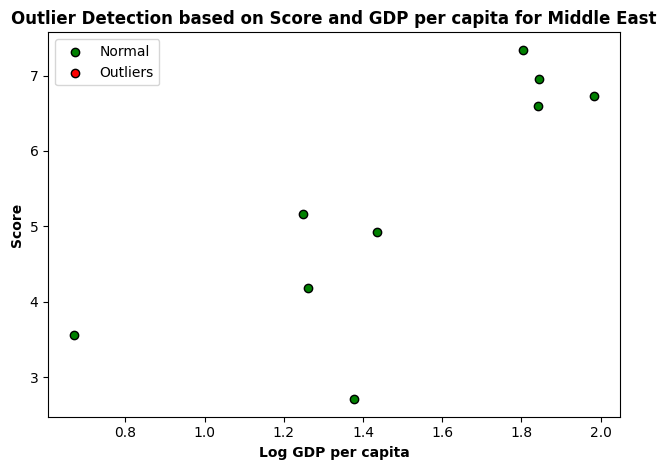

In [55]:
plt.scatter(middle_east_data['Log GDP per capita'],middle_east_data['score'],edgecolor='black',color='green',label='Normal')
plt.scatter(middleeast_gdp_outliers['Log GDP per capita'],middleeast_gdp_outliers['score'],edgecolor='black',color='red',label='Outliers')
plt.xlabel('Log GDP per capita',fontweight='bold')
plt.ylabel('Score',fontweight='bold')
plt.title('Outlier Detection based on Score and GDP per capita for Middle East',fontweight='bold')
plt.legend()
plt.tight_layout()

**Visualization**

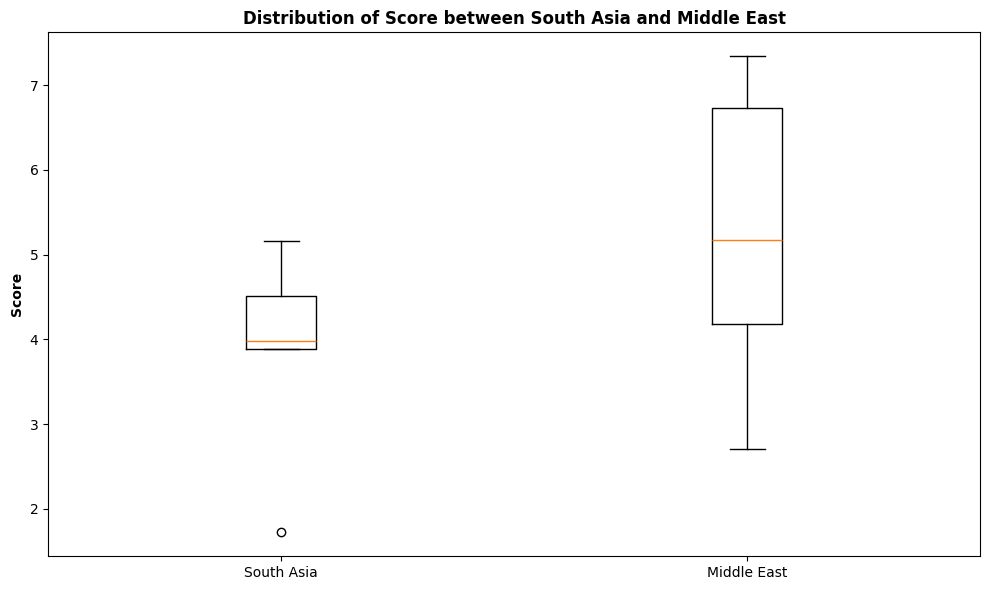

In [56]:
plt.figure(figsize=(10,6))
plt.boxplot([south_asia_data['score'],middle_east_data['score']],labels=['South Asia','Middle East'])
plt.ylabel('Score',fontweight='bold')
plt.title('Distribution of Score between South Asia and Middle East',fontweight='bold')
plt.tight_layout()